## Introducing U-NET

In this section, we perform a hyper-parameters search over the F1-UNET Model. This is a UNET model with the following features: 


*U-NET*:
* Base Filters: 21
* Kernel Size: [150, 50, 5]
  
*DNN*:
* Nodes: [470, 340, 330]

The purpose of this notebook is to implement L1L2 in the convolutional section with L1L2 and Dropout over the DNN section. 


## Used libraries

In [1]:
from AmaroXI.AmaroX.ai_functions import * 
from AmaroXI.AmaroX.UNET import *
from AmaroXI.AmaroX.DNN import *
from AmaroXI.AmaroX.data_manipulation import *
from AmaroXI.AmaroX.utilities import *

import keras_tuner
import pandas as pd

2025-09-21 23:18:32.216617: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 23:18:33.052387: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/intel/oneapi/vtune/2023.2.0/lib64/:/opt/gaussian//g16/bsd:/opt/gaussian//g16:/opt/TeraChem/TeraChem/lib:/usr/local/cuda/lib64:/opt/gaussian//g16/bsd:/opt/gaussian//g16:/opt/TeraChem/TeraChem/lib:/usr/local/cuda/lib64:/opt/intel/oneapi/vtune/2023.2.0/lib64/:/opt/gaussian//g16/bsd:/opt/gaussian//g16:/opt/TeraChem/TeraChem/lib:/usr/local/cuda/lib64:/opt/intel/oneapi/vtune/2023.2.0/lib64/:

## 1/10 Samples

In [2]:
n = 10
size = [
    1080000//n,
    108000//n, 
    12000//n
]

In [3]:
data = load_data_normalization_sample_General(
    '/home/bokhimi/Transmittance_Thesis/data_simulation/F1', 
    size = size
)

In [4]:
show_dimensions(data)


--------------------------------------------------
The dimensions of each dataset corresponds to:
--------------------------------------------------

Train: 
    x: (108000, 911, 1)
    y: (108000, 1)

Test: 
    x: (10800, 911, 1)
    y: (10800, 1)

Val:
    x: (1200, 911, 1)
    y: (1200, 1)
    


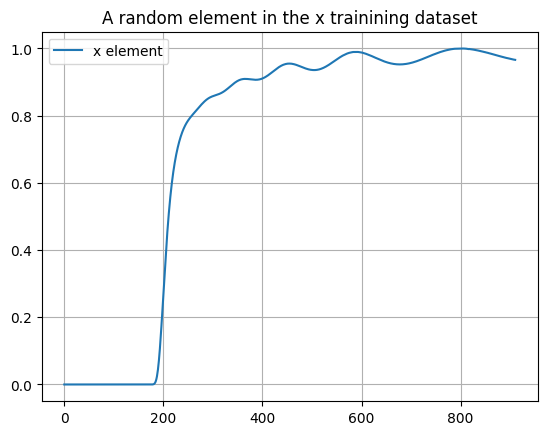

The corresponding y element -> [786.726]


In [5]:
plot_xy(data)

In [6]:
x_train, y_train, x_test, y_test, x_val, y_val = data
del data 

## GPU Allocation

In [7]:
! nvidia-smi

Sun Sep 21 23:18:36 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.57.02    Driver Version: 470.57.02    CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  Off  | 00000000:3B:00.0 Off |                    0 |
| N/A   34C    P0    26W / 250W |      0MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  Tesla V100-PCIE...  Off  | 00000000:5E:00.0 Off |                    0 |
| N/A   

In [8]:
get_gpu(2)

2025-09-21 23:18:37.201148: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 23:18:37.944999: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30971 MB memory:  -> device: 2, name: Tesla V100-PCIE-32GB, pci bus id: 0000:86:00.0, compute capability: 7.0


## Paths

In [9]:
name = 'DNN_UNET_F1_R'
folder_path = './models'
final_path = os.path.join(folder_path, name)

## Callbacks

In [10]:
callbacks = standard_callbacks(folder_name= name, 
                               folder_path= folder_path, 
                               patiences= [50, 1000])

## UNET Model

In [11]:
G_UNET

<function AmaroXI.AmaroX.UNET.G_UNET(inputs: tensorflow.python.framework.ops.Tensor, layers: int, unet_kernel: list, WIC: str, WRC, pad_type: str, unet_act_func='leaky_relu', pool: int = 12, stride: int = 3, final_func_act: str = 'relu', stride_conv: int = 1, pool_op: str = 'AP', pool_bool: bool = True)>

In [12]:
G_Dense

<function AmaroXI.AmaroX.DNN.G_Dense(inputs: tensorflow.python.framework.ops.Tensor, nodes: list, DP: int, n_final: int, act_func: str = 'leaky_relu', final_act_func: str = 'softmax', WI: str = 'he_normal', L1: float = 0.0, L2: float = 0.0, use_bias: bool = False) -> tensorflow.python.framework.ops.Tensor>

In [13]:
def _UNET(l1c:float, l2c:float, DP:int, L1:float, L2:float):
    
    inputs = keras.layers.Input((911,1))

    __UNET = G_UNET(
        inputs = inputs, 
        layers = 21,
        unet_kernel= [150, 50, 5], 
        WIC = 'he_normal', 
        WRC= keras.regularizers.L1L2(l1 = l1c, l2=l2c),
        pad_type='valid', 
        unet_act_func='leaky_relu', 
        pool = 4, 
        stride = 4, 
        final_func_act= 'relu', 
        stride_conv=1,
        pool_op= 'AP', 
    )

    _flatten = keras.layers.Flatten()(__UNET)

    _DNN = G_Dense(
        inputs = _flatten, 
        nodes = [470, 340, 330],
        DP = DP, 
        n_final = 1, 
        act_func = 'leaky_relu', 
        final_act_func= 'relu',
        WI = 'he_normal', 
        L1 = L1, 
        L2 = L2, 
        use_bias= True
    )
    

    return keras.models.Model(inputs = inputs, outputs = _DNN)

In [14]:
def compile_model(l1c:float, l2c:float, DP:int, L1:float, L2:float, optimizer, modelo):

  model = modelo(l1c = l1c, l2c=l2c, DP=DP, L1=L1, L2=L2)

  model.compile(optimizer = optimizer,
                loss = 'mae',
                metrics = ['mape'])

  return model

In [15]:
def build_model(hp):


  DP = hp.Int('Dropout', min_value = 0, max_value = 50, step = 5)

  L1 = hp.Choice('L1', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  L2 = hp.Choice('L2', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  l1c = hp.Choice('L1C', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  l2c = hp.Choice('L2C', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  optimizer = hp.Choice('optimizer', ['adam'])

  if optimizer == 'adam': opt = keras.optimizers.Adam(
        learning_rate = 0.001
    )

  elif optimizer == 'sgd': opt = keras.optimizers.SGD(
        learning_rate = 0.001
    )

  elif optimizer == 'adagrad': opt = keras.optimizers.Adagrad(
        learning_rate = 0.001
    )


  model_f = compile_model(
      L1 = L1, 
      L2 = L2, 
      l1c = l1c, 
      l2c = l2c,
      DP = DP,
      optimizer = optimizer, 
      modelo = _UNET)

  return model_f

In [16]:
build_model(keras_tuner.HyperParameters())

In [17]:
tuner = keras_tuner.BayesianOptimization(
    hypermodel=build_model,
    objective= keras_tuner.Objective('val_mape', 'min') ,
    max_trials= 50, # Set to 3
    executions_per_trial = 2,
    overwrite=True,
    directory= final_path,
    project_name="UNET-F1-R-KT",
)

In [18]:
tuner.search_space_summary()

Search space summary
Default search space size: 6
Dropout (Int)
{'default': None, 'conditions': [], 'min_value': 0, 'max_value': 50, 'step': 5, 'sampling': 'linear'}
L1 (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0], 'ordered': True}
L2 (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0], 'ordered': True}
L1C (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0], 'ordered': True}
L2C (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam'], 'ordered': False}


In [19]:
tuner.search(x_train, y_train, epochs=10, validation_data=(x_test, y_test), batch_size=512)


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
5                 |5                 |Dropout
1                 |1                 |L1
0.0001            |0.0001            |L2
1e-06             |1e-06             |L1C
0.0001            |0.0001            |L2C
adam              |adam              |optimizer

Epoch 1/10


2025-09-21 23:18:50.116273: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8302
2025-09-21 23:18:52.187099: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x2ad5000333b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-21 23:18:52.187215: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Tesla V100-PCIE-32GB, Compute Capability 7.0
2025-09-21 23:18:52.203089: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-21 23:18:52.426974: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


KeyboardInterrupt: 

In [ ]:
file_path = os.path.join(final_path, 'best_models.txt')

with open(file_path, "w") as file:
    # Save the original stdout
    original_stdout = sys.stdout
    try:
        sys.stdout = file  # Redirect stdout to the file
        tuner.results_summary()  # Call your function
    finally:
        sys.stdout = original_stdout

